# 02 特征分析
分析 MFCC 和 Mel 频谱图特征，对比不同情感类别的声学特征差异。

In [1]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 自动查找项目根目录
for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
    if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
        PROJECT_ROOT = _candidate
        break
else:
    raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f'项目根目录: {PROJECT_ROOT}')

from utils.audio_utils import load_config, EMOTION_LABELS, EMOTION_NAMES_ZH, EMOTION_COLORS

cfg = load_config()
print('配置加载完成')

项目根目录: /root/identifier
配置加载完成



libgomp: Invalid value for environment variable OMP_NUM_THREADS


## 1. 加载特征数据

In [ ]:
features_dir = cfg['paths']['features']
print(f'当前工作目录: {os.getcwd()}')
print(f'特征根目录: {os.path.abspath(features_dir)}')
print(f'特征根目录存在: {os.path.isdir(features_dir)}')

# 诊断：列出实际目录结构
if os.path.isdir(features_dir):
    for item in sorted(os.listdir(features_dir)):
        sub = os.path.join(features_dir, item)
        if os.path.isdir(sub):
            children = os.listdir(sub)
            print(f'  {item}/ -> {children}')

all_mfcc = []
all_mel = []
all_labels = []

for subset in ('ravdess', 'casia', 'tess', 'esd'):
    for feat_type, store in [('mfcc', all_mfcc), ('mel', all_mel)]:
        feat_dir = os.path.join(features_dir, subset, feat_type)
        if not os.path.isdir(feat_dir):
            print(f'  [跳过] 目录不存在: {feat_dir}')
            continue
        for label_name in sorted(os.listdir(feat_dir)):
            label_dir = os.path.join(feat_dir, label_name)
            if not os.path.isdir(label_dir) or label_name not in EMOTION_LABELS:
                continue
            for npy_path in sorted(glob.glob(os.path.join(label_dir, '*.npy'))):
                feat = np.load(npy_path)
                store.append(feat)
                if feat_type == 'mfcc':
                    all_labels.append(label_name)

print(f'\nMFCC 样本数: {len(all_mfcc)}')
print(f'Mel 样本数: {len(all_mel)}')
print(f'标签数: {len(all_labels)}')

当前工作目录: /root/identifier
特征根目录: /root/identifier/data/features
特征根目录存在: True
  casia/ -> ['mel', 'mfcc']
  esd/ -> ['mel', 'mfcc']
  ravdess/ -> ['mel', 'mfcc']
  tess/ -> ['mel', 'mfcc']

MFCC 样本数: 2640
Mel 样本数: 2640
标签数: 2640


## 2. 不同情感的平均 Mel 频谱图

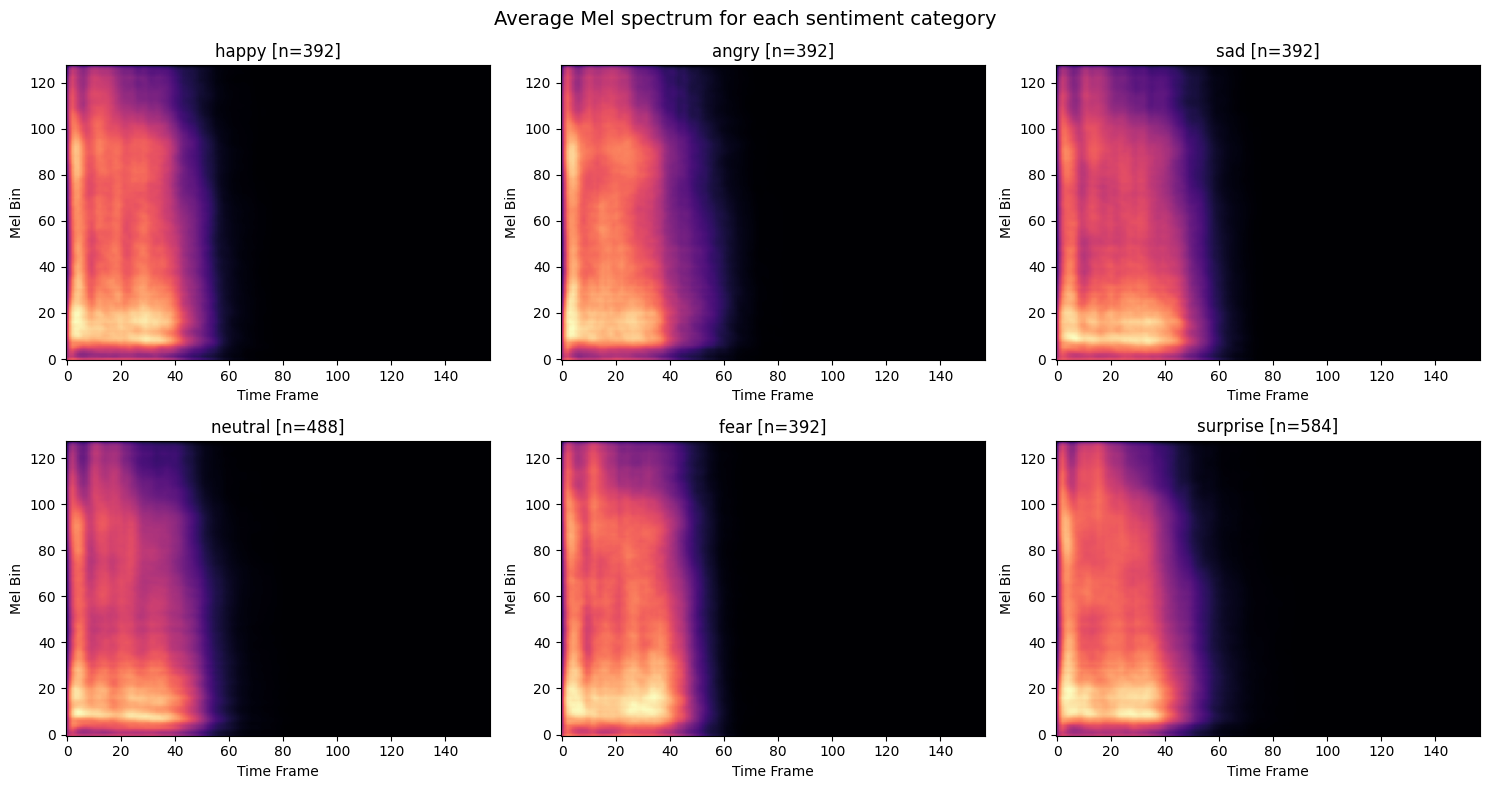

In [3]:
if all_mel:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, emotion in enumerate(EMOTION_LABELS):
        indices = [j for j, l in enumerate(all_labels) if l == emotion]
        if not indices:
            axes[i].set_title(f'{emotion} (no data)')
            continue
        avg_mel = np.mean([all_mel[j] for j in indices], axis=0)
        im = axes[i].imshow(avg_mel, aspect='auto', origin='lower', cmap='magma')
        axes[i].set_title(f'{emotion} [n={len(indices)}]')
        axes[i].set_ylabel('Mel Bin')
        axes[i].set_xlabel('Time Frame')
    
    plt.suptitle('Average Mel spectrum for each sentiment category', fontsize=14)
    plt.tight_layout()
    plt.show()

## 3. MFCC 统计特征 t-SNE 降维可视化

In [4]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 自动查找项目根目录
for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
    if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
        PROJECT_ROOT = _candidate
        break
else:
    raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f'项目根目录: {PROJECT_ROOT}')

from utils.audio_utils import load_config, EMOTION_LABELS, EMOTION_NAMES_ZH, EMOTION_COLORS

cfg = load_config()
print('配置加载完成')

项目根目录: /root/identifier
配置加载完成


## 4. 各情感 MFCC 系数均值对比

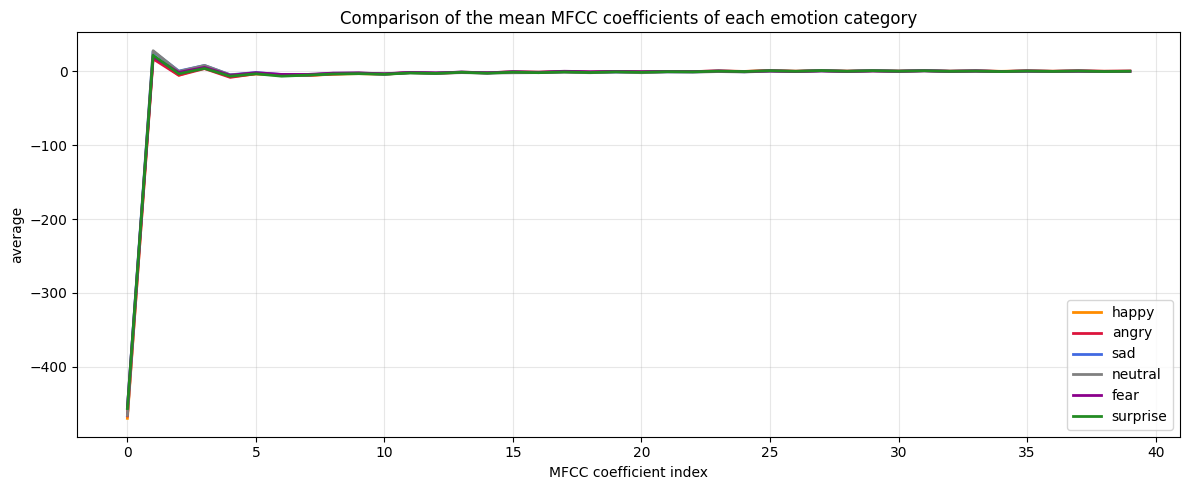

In [5]:
if all_mfcc:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(all_mfcc[0].shape[0])
    
    for emotion in EMOTION_LABELS:
        indices = [j for j, l in enumerate(all_labels) if l == emotion]
        if not indices:
            continue
        avg = np.mean([np.mean(all_mfcc[j], axis=1) for j in indices], axis=0)
        ax.plot(x, avg, label=emotion,
                color=EMOTION_COLORS[emotion], linewidth=2)
    
    ax.set_xlabel('MFCC coefficient index')
    ax.set_ylabel('average')
    ax.set_title('Comparison of the mean MFCC coefficients of each emotion category')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()